In [ ]:
from google.colab import drive
drive.mount('/content/drive', readonly=True)
!mkdir /content/dataset
!tar -xf '/content/drive/My Drive/ECE 1508 APLDL/dataset/OCT_clean.tar' -C /content/dataset

Mounted at /content/drive


In [ ]:
API_KEY=##

In [ ]:
from openai import OpenAI

client = OpenAI(api_key=API_KEY)

In [ ]:
import numpy as np
from PIL import Image
import io
import base64

def generate_patient_explanation(disease_name: str, img: np.ndarray) -> str:

    # System message
    system_message = {
        "role": "system",
        "content": f"You are a friendly and empathetic medical assistant."
        "Your goal is to explain complex medical diagnoses related to the eye (specifically from OCT scans) in simple,"
        "easy-to-understand language for patients."
        "Avoid medical jargon. Focus on what the disease is and how it affects the patient."
        "Do not give medical advice."
    }

    # User prompt
    user_prompt = (
        f"Please explain {disease_name} in a patient-friendly way. "
        "Keep the language simple and avoid medical jargon. "
        "This is for someone who just received an OCT result. "
        "If the OCT image is provided, incorporate it in the explanation."
    )

    # Convert numpy array to JPEG Base64
    img = Image.fromarray(img).convert("RGB")
    img = img.resize((224, 224))
    buffer = io.BytesIO()
    img.save(buffer, format="JPEG", quality=85)
    img_b64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

    # Messages with correct content-block format
    messages = [
        system_message,
        {
            "role": "user",
            "content": [
                {"type": "text", "text": user_prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}},
            ]
        }
    ]

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=messages,
            temperature=0.7
        )
        return response.choices[0].message.content.strip()

    except Exception as e:
        return f"Error generating explanation: {e}"


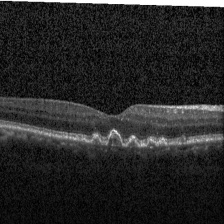

Patient-Friendly Explanation for Drusen:
Drusen are small, yellowish spots that can form on the layer of tissue at the back of your eye called the retina. They are made up of waste products from the retina's cells. While drusen can happen as we age, they are important to monitor because they can be a sign of eye health issues, especially related to a condition called age-related macular degeneration (AMD).

In the OCT image you see here, drusen might appear as little bumps or irregularities in the layers of the retina. While having some drusen is common, especially in older adults, it's essential to keep an eye on them because they can affect your vision over time.

Most importantly, having drusen doesn't mean you will definitely have vision problems, but it’s something your eye doctor will want to keep track of during your visits. They might suggest regular check-ups to monitor your eye health. If you have any questions or concerns about what this means for you, it's always best to ta

In [ ]:
import numpy as np
from PIL import Image

disease = "Drusen"
image_path = "/content/dataset/OCT_clean/test/DRUSEN/DRUSEN-1021298-1_original.jpeg"

# Load the image
try:
    img = Image.open(image_path)
    display(img)
    img_array = np.array(img)
    explanation = generate_patient_explanation(disease, img_array)
    print(f"Patient-Friendly Explanation for {disease}:\n{explanation}")
except FileNotFoundError:
    print(f"Warning: Image not found at {image_path}. Using a dummy image instead.")
